In [ ]:
# ドライブのマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# カレントディレクトリの移動・確認
%cd drive/MyDrive/cnn_visualization_workspace
!pwd

/content/drive/MyDrive/cnn_visualization_workspace
/content/drive/MyDrive/cnn_visualization_workspace


In [ ]:
# ライブラリのインポート
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

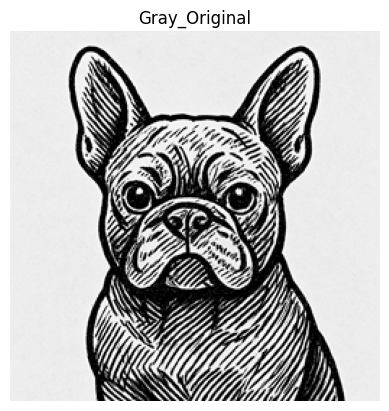

In [ ]:
# 画像読み込み（グレースケール）
img_gray = cv2.imread("data/input/inu_grayscale_256.jpg", cv2.IMREAD_GRAYSCALE)

# 表示
plt.imshow(img_gray, cmap='gray')
plt.title("Gray_Original")
plt.axis("off")
plt.show()

# 前処理
# 正規化と型変換
img_gray_tf_input = img_gray.astype("float32") / 255.0
# 入力を (1, 256, 256, 1) に変形してTensorに
img_tensor_gray = tf.convert_to_tensor(img_gray_tf_input.reshape(1, 256, 256, 1), dtype=tf.float32)

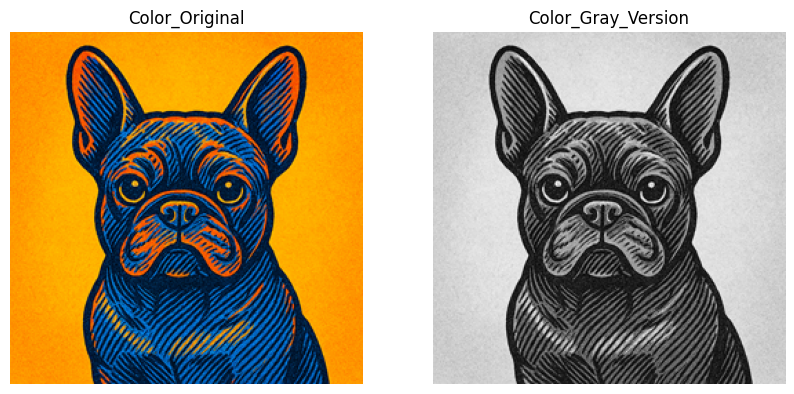

In [ ]:
# 画像読み込み（カラー）
img_color = cv2.imread("data/input/inu_color_256.jpg", cv2.IMREAD_COLOR)
# BGR → RGB に変換（matplotlib表示にも使える）
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_rgb_gray = cv2.cvtColor(img_color_rgb, cv2.COLOR_RGB2GRAY)

# 表示
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# オリジナルカラー画像
axs[0].imshow(img_color_rgb)
axs[0].set_title("Color_Original")
axs[0].axis("off")
# オリジナルカラー画像をグレースケール化した画像
axs[1].imshow(img_color_rgb_gray, cmap='gray')
axs[1].set_title("Color_Gray_Version")
axs[1].axis("off")
plt.show()

# 前処理
# 正規化と型変換
img_color_tf_input = img_color_rgb.astype("float32") / 255.0
# 入力を (1, 256, 256, 1) に変形してTensorに
img_tensor_color = tf.convert_to_tensor(img_color_tf_input.reshape(1, 256, 256, 3), dtype=tf.float32)

input出力: (1, 256, 256, 1)
Conv2D出力: (1, 256, 256, 8)
MaxPool出力: (1, 128, 128, 8)
Flatten出力: (1, 131072)
Dense出力: (1, 8)


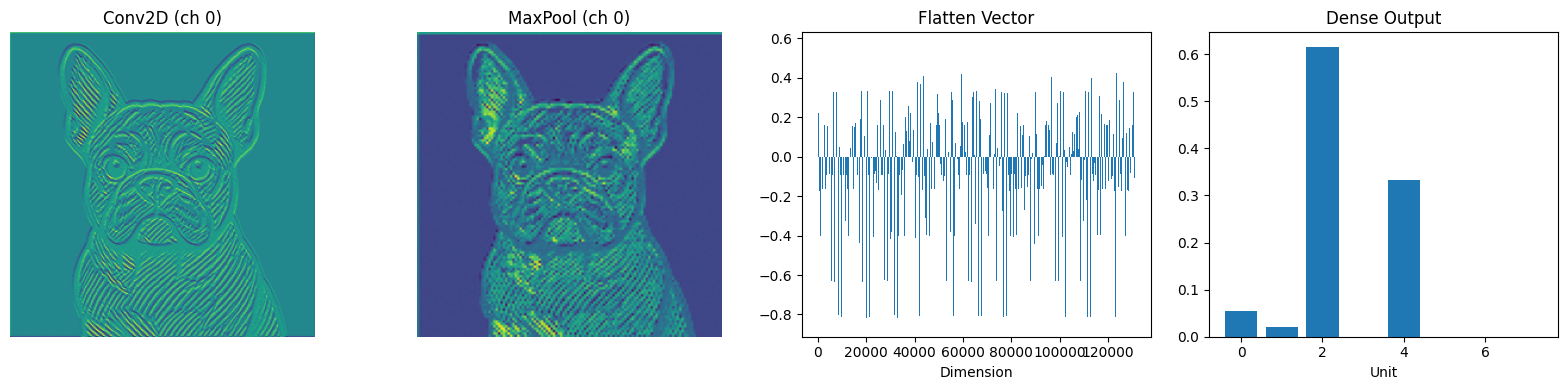

In [ ]:
# ＝＝＝＝＝＝＝Functional APIで実装＝＝＝＝＝＝＝
# グレースケール画像を使用

# 入力定義
inputs = tf.keras.Input(shape=(256, 256, 1), name="input_layer")

# モデル構成：Conv → MaxPool → Flatten → Dense
x = tf.keras.layers.Conv2D(filters=8, kernel_size=3, strides=1, padding='same', name="conv")(inputs)
x = tf.keras.layers.MaxPooling2D(pool_size=2, strides=2, name="maxpool")(x)
x = tf.keras.layers.Flatten(name="flatten")(x)
outputs = tf.keras.layers.Dense(8, activation='relu', name="dense")(x)

# モデル構築
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 中間層出力モデル
intermediate_model = tf.keras.Model(
    inputs=model.input,
    outputs=[layer.output for layer in model.layers]
)

# model入力→出力
input_out, conv_out, pool_out, flatten_out, dense_out = intermediate_model(img_tensor_gray)

# 出力確認
print("input出力:", input_out.shape)
print("Conv2D出力:", conv_out.shape)
print("MaxPool出力:", pool_out.shape)
print("Flatten出力:", flatten_out.shape)
print("Dense出力:", dense_out.shape)

# 可視化（Conv → Pool → Flatten → Dense）
plt.figure(figsize=(16, 4))

# Conv2Dの出力（ch=0）
plt.subplot(1, 4, 1)
plt.imshow(conv_out[0, :, :, 0], cmap='viridis')
plt.title("Conv2D (ch 0)")
plt.axis('off')

# MaxPoolingの出力（ch=0）
plt.subplot(1, 4, 2)
plt.imshow(pool_out[0, :, :, 0], cmap='viridis')
plt.title("MaxPool (ch 0)")
plt.axis('off')

# Flattenの出力を棒グラフ
plt.subplot(1, 4, 3)
plt.bar(np.arange(flatten_out.shape[-1]), flatten_out[0].numpy())
plt.title("Flatten Vector")
plt.xlabel("Dimension")

# Denseの出力を棒グラフ
plt.subplot(1, 4, 4)
plt.bar(np.arange(dense_out.shape[-1]), dense_out[0].numpy())
plt.title("Dense Output")
plt.xlabel("Unit")

plt.tight_layout()
plt.show()

input出力: (1, 256, 256, 3)
Conv2D出力: (1, 256, 256, 8)
MaxPool出力: (1, 128, 128, 8)
Flatten出力: (1, 131072)
Dense出力: (1, 8)


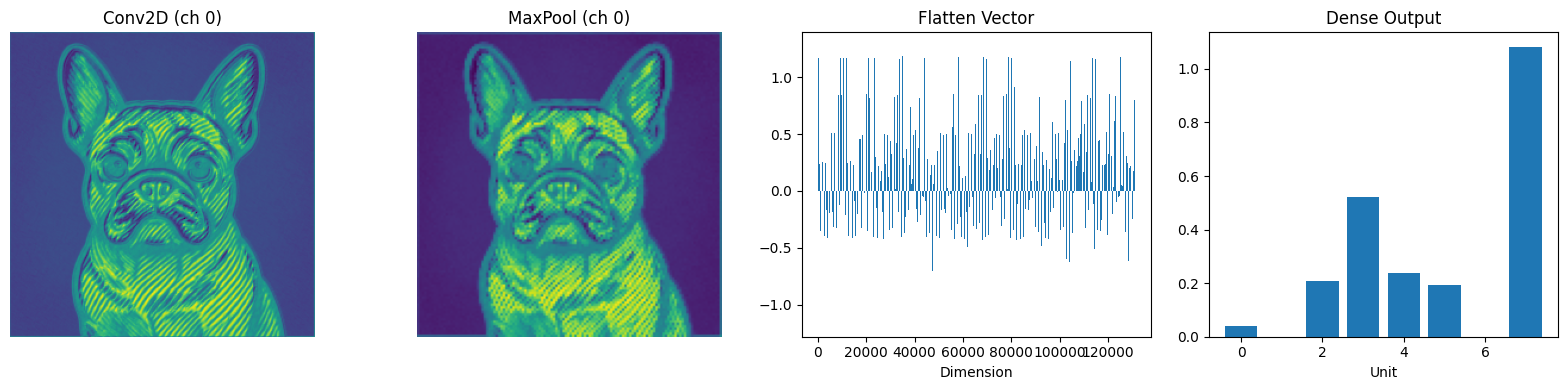

In [ ]:
# カラー画像を使用

# 入力定義
inputs = tf.keras.Input(shape=(256, 256, 3), name="input_layer")

# モデル構成：Conv → MaxPool → Flatten → Dense
x = tf.keras.layers.Conv2D(filters=8, kernel_size=3, strides=1, padding='same', name="conv")(inputs)
x = tf.keras.layers.MaxPooling2D(pool_size=2, strides=2, name="maxpool")(x)
x = tf.keras.layers.Flatten(name="flatten")(x)
outputs = tf.keras.layers.Dense(8, activation='relu', name="dense")(x)


# モデル構築
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 中間層出力モデル
intermediate_model = tf.keras.Model(
    inputs=model.input,
    outputs=[layer.output for layer in model.layers]
)

# model入力→出力
input_out, conv_out, pool_out, flatten_out, dense_out = intermediate_model(img_tensor_color)

# 出力確認
print("input出力:", input_out.shape)
print("Conv2D出力:", conv_out.shape)
print("MaxPool出力:", pool_out.shape)
print("Flatten出力:", flatten_out.shape)
print("Dense出力:", dense_out.shape)

# 可視化（Conv → Pool → Flatten → Dense）
plt.figure(figsize=(16, 4))

# Conv2Dの出力（ch=0）
plt.subplot(1, 4, 1)
plt.imshow(conv_out[0, :, :, 0], cmap='viridis')
plt.title("Conv2D (ch 0)")
plt.axis('off')

# MaxPoolingの出力（ch=0）
plt.subplot(1, 4, 2)
plt.imshow(pool_out[0, :, :, 0], cmap='viridis')
plt.title("MaxPool (ch 0)")
plt.axis('off')

# Flattenの出力を棒グラフ
plt.subplot(1, 4, 3)
plt.bar(np.arange(flatten_out.shape[-1]), flatten_out[0].numpy())
plt.title("Flatten Vector")
plt.xlabel("Dimension")

# Denseの出力を棒グラフ
plt.subplot(1, 4, 4)
plt.bar(np.arange(dense_out.shape[-1]), dense_out[0].numpy())
plt.title("Dense Output")
plt.xlabel("Unit")

plt.tight_layout()
plt.show()
